# 基于 GBS-RVFL 与 GBS-ELM 的 MNIST 手写数字识别教程

这个 notebook 演示一种基于高斯玻色采样（Gaussian Boson Sampling, GBS）表征、最小二乘输出层的手写数字识别流程。示例通过九章 SDK 的本地任务接口运行，适合放在云平台 JupyterLab 中作为预置教学用例。

论文地址：
- [Enhanced Image Recognition Using Gaussian Boson Sampling](https://arxiv.org/abs/2506.19707)


## 原理说明

这一部分分成两块：
1. 背景知识介绍
2. 具体算法流程

## 第一部分：背景知识介绍

### 1. 九章 4.0 光量子计算机
“九章”系列沿着高斯玻色采样路线发展，是一种典型的光量子计算技术路线。它不是通过量子门逐个操控量子比特，而是通过制备压缩态光源，让光子在大规模干涉网络中演化，并通过探测得到复杂的采样分布。

从应用角度看，本教程关注的问题是：由 GBS 统计结构诱导出来的特征表示，能否为机器学习任务提供有价值的信息。

### 2. 什么是高斯玻色采样
高斯玻色采样（Gaussian Boson Sampling, GBS）是光量子计算中的一种采样模型。它的输出不是一个确定答案，而是从压缩态输入、线性光学网络和光子探测共同定义的概率分布中反复采样。

它与机器学习相关，是因为采样分布中包含复杂的高阶相关性，这些相关性可以被看作一种非线性特征映射。教程中的 GBS 层不是直接完成分类，而是为后续分类器提供结构化特征。

### 3. 什么是 ELM
ELM（Extreme Learning Machine，极限学习机）可以理解为一种单隐层学习框架：前面的特征映射固定，训练阶段只求解输出层权重。输出层可以通过最小二乘或岭回归闭式求解，不需要反向传播。

在本教程中，GBS 特征层承担“固定特征映射”的角色，最后通过闭式线性输出层完成数字分类。

### 4. 什么是 RVFL
RVFL（Random Vector Functional Link）与 ELM 接近，但额外保留了原始输入到输出层的直连通路。也就是说，输出层会同时使用：
- GBS 特征；
- 原始图像特征。

因此可以区分两个模型：
- **GBS-ELM**：只使用 GBS 特征；
- **GBS-RVFL**：同时使用 GBS 特征和原始图像特征。

### 5. 为什么要做这个实验
这个实验的意义不只是“把 MNIST 分对”，更重要的是观察 GBS 风格的特征表示是否能给经典机器学习流程提供有效补充。通过比较 GBS-RVFL 和 GBS-ELM，可以看到原始输入直连通路、PCA 维度、特征数量等参数对分类效果的影响。

## 第二部分：具体算法流程

整体流程如下：
1. 将手写数字图像展平成一维向量；
2. 通过 PCA 压缩维度；
3. 将降维后的特征送入 SDK 本地 GBS 风格特征层；
4. 根据配置决定是否拼接原始图像特征；
5. 通过最小二乘/岭回归求解输出层权重；
6. 在测试集上预测并绘制混淆矩阵。


---

## 教程路线图

教程按照下面的顺序完成实验：
1. 导入九章 SDK 本地任务接口和绘图工具。
2. 加载并展平手写数字数据集。
3. 训练 `GBS-RVFL` 版本。
4. 通过准确率和混淆矩阵观察预测效果。
5. 复用已经提取好的 GBS 特征，训练 `GBS-ELM` 版本。
6. 修改关键参数，观察表示规模、训练时间和准确率之间的变化。


---

## 1. 导入与环境准备

加载科学计算、可视化工具，以及九章 SDK 中的本地手写数字识别任务接口。绘图字体会优先使用常见中文字体；如果当前环境没有中文字体，图标题会自动切换为英文，避免 Matplotlib 的缺字警告。


In [1]:
from typing import Literal

import matplotlib.pyplot as plt
from matplotlib import font_manager

from jiuzhang.local.mnist import GBSMNISTClassifier, load_mnist_data


def configure_plot_font():
    # 配置 Matplotlib 字体，优先选择当前系统已有的常见中文字体。
    preferred_fonts = [
        "Microsoft YaHei",
        "SimHei",
        "SimSun",
        "Noto Sans CJK SC",
        "WenQuanYi Micro Hei",
        "Arial Unicode MS",
    ]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in preferred_fonts:
        if font_name in available_fonts:
            plt.rcParams["font.family"] = "sans-serif"
            plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
            plt.rcParams["axes.unicode_minus"] = False
            return font_name

    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["axes.unicode_minus"] = False
    return None


PLOT_FONT = configure_plot_font()


def plot_text(chinese_text, english_text):
    # 当前环境有中文字体时使用中文，否则使用英文避免缺字警告。
    return chinese_text if PLOT_FONT else english_text


print(f"当前绘图字体: {PLOT_FONT or 'DejaVu Sans (英文图标题)'}")


当前绘图字体: Microsoft YaHei


---

## 2. 加载 MNIST 数据

SDK 提供 `load_mnist_data` 作为数据加载入口。默认 `source="digits"` 使用 scikit-learn 内置手写数字数据集，不需要联网，适合云平台 Notebook 首次体验；如果需要完整 MNIST 784 数据集，可以把 `source` 改为 `"openml"`。

加载后，每张图像会被展平成一维向量，标签保持为 `0` 到 `9` 的整数类别。


In [2]:
DATA_SOURCE: Literal["digits", "openml", "auto"] = "digits"
TRAIN_SIZE: int = 1200
TEST_SIZE: int = 300
N_COMPONENTS: int = 32
INDEX_NUMBER: int = 256
RANDOM_STATE: int = 7

experiment_config = {
    "source": DATA_SOURCE,
    "train_size": TRAIN_SIZE,
    "test_size": TEST_SIZE,
    "n_components": N_COMPONENTS,
    "IndexNumber": INDEX_NUMBER,
    "random_state": RANDOM_STATE,
}

dataset = load_mnist_data(
    train_size=TRAIN_SIZE,
    test_size=TEST_SIZE,
    source=DATA_SOURCE,
    random_state=RANDOM_STATE,
)

train_data = dataset.train_data
test_data = dataset.test_data
train_labels = dataset.train_labels
test_labels = dataset.test_labels

print(f"数据来源: {dataset.source}")
print(f"训练样本数: {len(train_data)}")
print(f"测试样本数: {len(test_data)}")
print(f"图像特征维度: {train_data.shape[1]}")


数据来源: sklearn-digits
训练样本数: 1200
测试样本数: 300
图像特征维度: 64


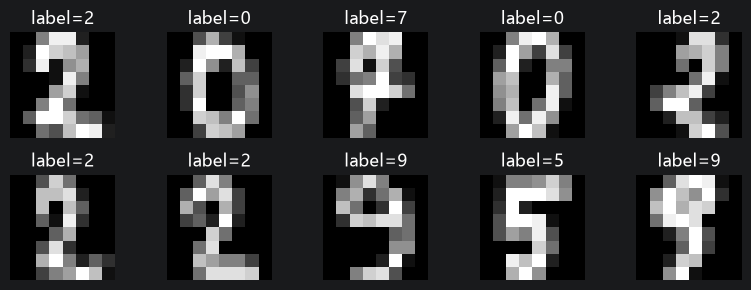

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(8, 3))
for ax, image, label in zip(axes.ravel(), train_data[:10], train_labels[:10], strict=True):
    ax.imshow(image.reshape(dataset.image_shape), cmap="gray")
    ax.set_title(f"label={label}")
    ax.axis("off")
plt.tight_layout()
plt.show()


---

## 3. 训练 GBS-RVFL 模型

`GBSMNISTClassifier.fit` 封装了完整流程：PCA 压缩、GBS 风格特征提取、可选的原始特征拼接，以及输出权重矩阵的闭式训练。

第一轮训练使用 `combine=True`，对应 **GBS-RVFL**。此时输出层会同时看到：
- 变换后的 GBS 特征；
- 原始图像特征。

`IndexNumber` 是为了兼容原用例的参数名，在 SDK 中也可以写成更直观的 `feature_count`。数值越大，本地生成的 GBS 风格特征越多，通常表达能力更强，但训练耗时也会增加。


In [4]:
gbs_classifier = GBSMNISTClassifier(
    n_components=N_COMPONENTS,
    feature_count=INDEX_NUMBER,
    random_state=RANDOM_STATE,
)

print("训练融合模型 GBS-RVFL (combine=True)...")
result = gbs_classifier.fit(
    train_data,
    train_labels,
    combine=True,
    IndexNumber=INDEX_NUMBER,
)
print(result)


训练融合模型 GBS-RVFL (combine=True)...
{'status': 'trained', 'mode': 'GBS-RVFL', 'n_components': 32, 'feature_count': 256, 'pca_explained_variance_ratio': 0.9671126102192988}


---

## 3A. 参数探索

这个 notebook 中最值得调整的参数主要有两个：

1. `n_components`  
表示进入 GBS 特征层之前，PCA 保留的主成分数量。数值太小可能丢失图像结构；数值太大会增加后续特征提取和训练成本。

2. `IndexNumber` / `feature_count`  
表示使用多少个 GBS 风格特征。数值增加通常会提升表示能力，但也会增加计算量，并不一定一直提升准确率。

比较实用的探索方式是：每次只修改一个参数，在同一组数据上分别比较 `GBS-RVFL` 和 `GBS-ELM` 的准确率与混淆矩阵。


In [5]:
sweep_values = {
    "n_components": [16, 32, 48],
    "IndexNumber": [128, 256, 512],
}


def evaluate_setting(combine: bool, n_components: int = 32, index_number: int = 256) -> dict[str, object]:
    classifier = GBSMNISTClassifier(
        n_components=n_components,
        feature_count=index_number,
        random_state=RANDOM_STATE,
    )
    classifier.fit(
        train_data,
        train_labels,
        combine=combine,
        IndexNumber=index_number,
    )
    setting_predictions = classifier.predict(test_data)
    setting_accuracy = (setting_predictions == test_labels).mean()
    return {
        "mode": "GBS-RVFL" if combine else "GBS-ELM",
        "n_components": n_components,
        "IndexNumber": index_number,
        "accuracy": float(setting_accuracy),
    }


# 可以取消下面注释，手动探索不同参数组合。
# evaluate_setting(combine=True, n_components=32, index_number=256)
# evaluate_setting(combine=False, n_components=32, index_number=256)
# [evaluate_setting(combine=True, n_components=k, index_number=256) for k in sweep_values["n_components"]]
# [evaluate_setting(combine=True, n_components=32, index_number=b) for b in sweep_values["IndexNumber"]]


## 4. 预测与混淆矩阵

使用训练好的 `GBS-RVFL` 模型在测试集上预测，计算准确率，并绘制混淆矩阵。混淆矩阵的行表示真实标签，列表示预测标签，对角线越集中，说明模型分类效果越稳定。


Accuracy (GBS-RVFL, combine=True): 0.9800


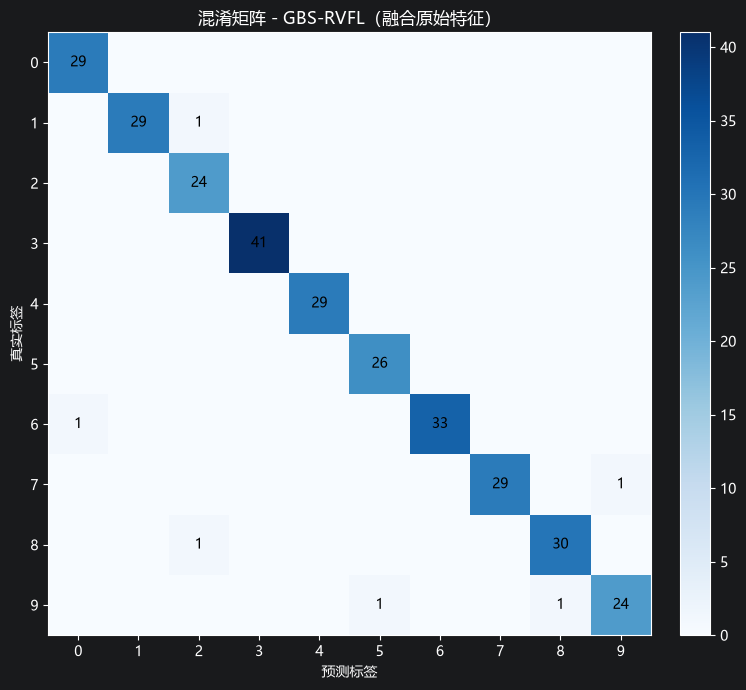

In [6]:
def plot_confusion_matrix(matrix, *, title_cn, title_en):
    fig, ax = plt.subplots(figsize=(8, 7))
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(plot_text(title_cn, title_en))
    ax.set_xlabel(plot_text("预测标签", "Predicted"))
    ax.set_ylabel(plot_text("真实标签", "True"))
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))

    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            value = int(matrix[row, col])
            if value:
                ax.text(col, row, str(value), ha="center", va="center", color="black")

    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


rvfl_predictions = gbs_classifier.predict(test_data)
rvfl_accuracy = (rvfl_predictions == test_labels).mean()
print(f"Accuracy (GBS-RVFL, combine=True): {rvfl_accuracy:.4f}")

rvfl_evaluation = gbs_classifier.evaluate(test_data, test_labels, reuse=True)
plot_confusion_matrix(
    rvfl_evaluation["confusion_matrix"],
    title_cn="混淆矩阵 - GBS-RVFL（融合原始特征）",
    title_en="Confusion Matrix - GBS-RVFL (combine=True)",
)


### 混淆矩阵解读（GBS-RVFL）

- 对角线上的数值越大，表示对应数字识别越准确。
- 非对角线上的数值表示混淆情况，需要重点关注形态接近的数字对。
- 与后面的 `GBS-ELM` 对比时，可以观察原始图像直连通路是否帮助模型保留更多笔画细节。


---

## 5. 训练 GBS-ELM 版本

为了单独观察 GBS 特征层的作用，第二轮把 `combine` 改为 `False`，对应 **GBS-ELM**。此时输出层只使用 GBS 特征，不再拼接原始图像特征。

这里使用 `reuse=True` 复用前面已经计算好的 GBS 特征，避免重复执行 PCA 和特征提取。


In [7]:
print("训练 GBS-ELM (combine=False, reuse=True)...")
result = gbs_classifier.fit(
    train_data,
    train_labels,
    combine=False,
    IndexNumber=INDEX_NUMBER,
    reuse=True,
)
print(result)


训练 GBS-ELM (combine=False, reuse=True)...
{'status': 'trained', 'mode': 'GBS-ELM', 'n_components': 32, 'feature_count': 256, 'pca_explained_variance_ratio': 0.9671126102192988}


## 6. 比较 GBS-RVFL 和 GBS-ELM

从实验角度可以比较：
1. 准确率差异；
2. 混淆矩阵的变化；
3. 调整 `n_components` 和 `IndexNumber` 时，训练耗时与表示规模之间的权衡。

通常可以观察到，`GBS-RVFL` 在一些容易混淆的数字上更有优势，因为它额外保留了原始图像特征；`GBS-ELM` 更适合观察 GBS 特征层本身的贡献。


Accuracy (GBS-ELM, combine=False, reuse=True): 0.9833


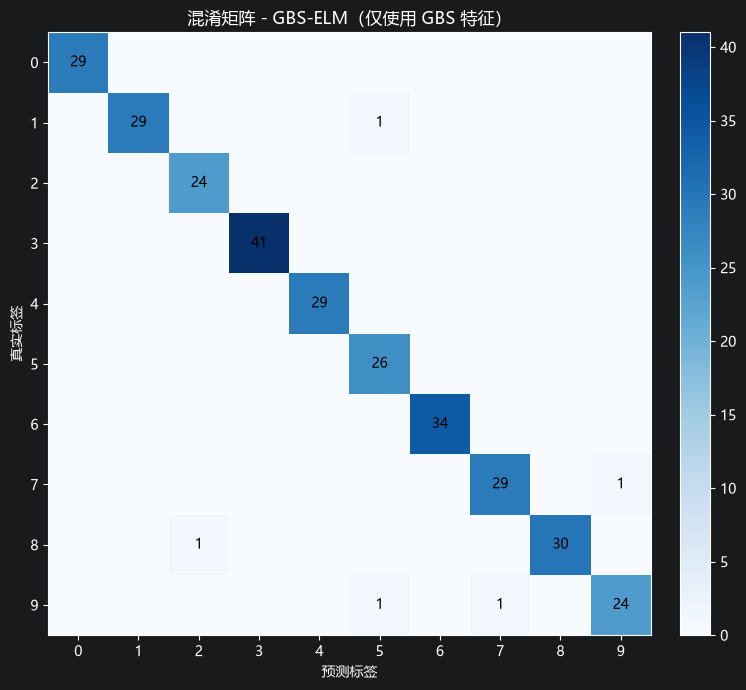

In [8]:
elm_predictions = gbs_classifier.predict(test_data, reuse=True)
elm_accuracy = (elm_predictions == test_labels).mean()
print(f"Accuracy (GBS-ELM, combine=False, reuse=True): {elm_accuracy:.4f}")

elm_evaluation = gbs_classifier.evaluate(test_data, test_labels, reuse=True)
plot_confusion_matrix(
    elm_evaluation["confusion_matrix"],
    title_cn="混淆矩阵 - GBS-ELM（仅使用 GBS 特征）",
    title_en="Confusion Matrix - GBS-ELM (combine=False)",
)


### 混淆矩阵解读（GBS-ELM）

- 如果对角线仍然集中，说明只使用 GBS 特征也能形成有效表示。
- 如果相比 `GBS-RVFL` 出现更多非对角线误判，通常说明去掉原始图像直连通路后，某些局部笔画或灰度细节更容易丢失。
- 准确率和混淆矩阵应该一起看：准确率给出整体表现，混淆矩阵说明具体哪些数字对更容易被混淆。


---

## 总结

这个 notebook 展示了通过九章 SDK 本地任务接口运行手写数字识别实验的完整流程：
- `GBS-RVFL`：将 GBS 风格特征与原始图像特征拼接后分类；
- `GBS-ELM`：完全依赖 GBS 风格特征分类。

后续可以通过修改 `experiment_config`，或者调用 `evaluate_setting(...)`，每次只改变一个参数，观察准确率、混淆矩阵和计算耗时的变化。
